In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, Subset
import numpy as np
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [2]:
from torchvision import transforms

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# transform with flips for data augmentation
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5), # <--- New: Randomly flip images
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Keep validation simple (no flips)
val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

In [3]:
import pandas as pd
import os
from PIL import Image
from torch.utils.data import Dataset

class KaggleCelebA(Dataset):
    def __init__(self, csv_path, img_dir, transform=None, attr_name="Male"):
        self.df = pd.read_csv(csv_path)
        self.img_dir = img_dir
        self.transform = transform
        self.attr_name = attr_name
        
        if self.attr_name not in self.df.columns:
            raise ValueError(f"Attribute {attr_name} not found in CSV columns")

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_name = self.df.iloc[idx, 0] 
        img_path = os.path.join(self.img_dir, img_name)
        
        image = Image.open(img_path).convert('RGB')
        
        label_raw = self.df.iloc[idx][self.attr_name]
        label = 1 if label_raw == 1 else 0
        
        if self.transform:
            image = self.transform(image)
            
        return image, label

csv_path = '/kaggle/input/celeba-dataset/list_attr_celeba.csv'
img_dir = '/kaggle/input/celeba-dataset/img_align_celeba/img_align_celeba'

print("Loading Custom CelebA...")
full_dataset = KaggleCelebA(
    csv_path=csv_path, 
    img_dir=img_dir, 
    transform=transform, 
    attr_name="Male"
)

print(f"Data loaded! Found {len(full_dataset)} images.")

Loading Custom CelebA...
Data loaded! Found 202599 images.


In [4]:
from torch.utils.data import random_split

# 1. Generate 10k random indices from the full dataset
total_len = len(full_dataset)
all_indices = torch.randperm(total_len)[:10000].tolist()

# 2. Split these 10k indices into Train (8k) and Val (2k)
split_idx = int(0.8 * len(all_indices))
train_indices = all_indices[:split_idx]
val_indices = all_indices[split_idx:]

# 3. Create the Subsets with correct transforms
# We create two separate dataset objects so they can have different transforms
train_base = KaggleCelebA(csv_path, img_dir, transform=train_transform)
val_base = KaggleCelebA(csv_path, img_dir, transform=val_transform)

train_ds = Subset(train_base, train_indices)
val_ds = Subset(val_base, val_indices)

# 4. Loaders
train_loader = DataLoader(train_ds, batch_size=64, shuffle=True, num_workers=2)
val_loader = DataLoader(val_ds, batch_size=64, shuffle=False, num_workers=2)

print(f"Training on {len(train_ds)} images.")
print(f"Validating on {len(val_ds)} images.") # Should be ~2000


Training on 8000 images.
Validating on 2000 images.


In [5]:
#We load pre-trained resnet18
model = models.resnet18(weights='IMAGENET1K_V1')

#Freeze early layers
for param in model.parameters():
    param.requires_grad = False

# UNFREEZE the last generic block (layer4) so it learns "Face Features"
for param in model.layer4.parameters():
    param.requires_grad = True

#Change the final layer to output 1 number
model.fc = nn.Linear(model.fc.in_features, 1)
model = model.to(device)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 229MB/s]


In [6]:
from tqdm.notebook import tqdm # Use the notebook-friendly progress bar

#Settings
batch_size = 64
learning_rate = 1e-4
epochs = 5

#We define Loss and Optimizer
criterion = nn.BCEWithLogitsLoss()
# Use a lower learning rate since we are fine-tuning now
# bu filterı hiç anlamadan koydum
optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=learning_rate)

print("Starting training...")

#Training :
for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    # Wrap train_loader with tqdm for a progress bar
    progress_bar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}")
    
    for images, labels in progress_bar:
        images, labels = images.to(device), labels.float().unsqueeze(1).to(device)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

        # Update progress bar description with current loss
        progress_bar.set_postfix(loss=loss.item())
        
    # Validation Phase
    model.eval() # Set to evaluation mode
    correct = 0
    total = 0
    with torch.no_grad(): # Don't calculate gradients for validation
        for images, labels in val_loader:
            images, labels = images.to(device), labels.float().unsqueeze(1).to(device)
            outputs = model(images)
            predicted = (torch.sigmoid(outputs) > 0.5).float()
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            
    val_acc = 100 * correct / total
    print(f"Epoch {epoch+1}, Loss: {running_loss/len(train_loader):.4f}, Val Accuracy: {val_acc:.2f}%")


Starting training...


Epoch 1/5:   0%|          | 0/125 [00:00<?, ?it/s]

Epoch 1, Loss: 0.1654, Val Accuracy: 96.70%


Epoch 2/5:   0%|          | 0/125 [00:00<?, ?it/s]

Epoch 2, Loss: 0.0684, Val Accuracy: 97.10%


...

Epoch 3, Loss: 0.0353, Val Accuracy: 97.50%


Epoch 4/5:   0%|          | 0/125 [00:00<?, ?it/s]

Epoch 4, Loss: 0.0194, Val Accuracy: 97.70%


Epoch 5/5:   0%|          | 0/125 [00:00<?, ?it/s]

Epoch 5, Loss: 0.0145, Val Accuracy: 97.50%


In [7]:
torch.save(model.state_dict(), '/kaggle/working/classifier_gender.pth')
print("Model saved!")

Model saved!


In [8]:
# Test the loader
temp_images, temp_labels = next(iter(train_loader))
print("Image batch shape:", temp_images.shape)
print("Label batch shape:", temp_labels.shape)
print("First 5 labels:", temp_labels[:5]) # Should be 0s and 1s

Image batch shape: torch.Size([64, 3, 224, 224])
Label batch shape: torch.Size([64])
First 5 labels: tensor([0, 0, 1, 0, 0])


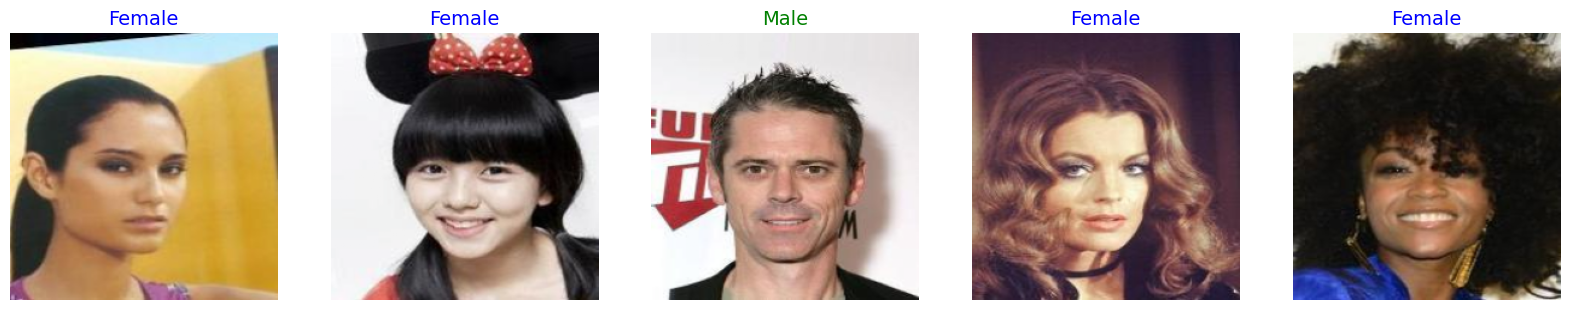

In [9]:
# Visualize the results:

# Define the inverse of the ImageNet normalization
def denormalize(tensor):
    # These must match the values used in your 'transforms.Normalize'
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1).to(tensor.device)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1).to(tensor.device)
    
    # Reverse the formula: x = (y * std) + mean
    tensor = tensor * std + mean
    return tensor.clamp(0, 1) # Ensure we stay within valid color range

def to_img(tensor):
    # Un-normalize first
    tensor = denormalize(tensor)
    # Move to CPU and rearrange dims from (Channels, Height, Width) to (Height, Width, Channels)
    img = tensor.permute(1, 2, 0).cpu().numpy()
    return img

# Plotting Code
fig, ax = plt.subplots(1, 5, figsize=(20, 5))
for i in range(5):
    # Get image and label
    img_tensor = temp_images[i]
    label = temp_labels[i].item()
    
    # Display
    ax[i].imshow(to_img(img_tensor))
    ax[i].axis('off')
    
    # Set Title
    title = 'Male' if label == 1 else 'Female'
    color = 'green' if label == 1 else 'blue'
    ax[i].set_title(title, color=color, fontsize=14)

plt.show()